# Modellering av icke-linjär elförbrukning mot temperatur med PROC GAMPL

## Sammanfattning

Elförbrukningen beror på temperaturen på ett starkt olinjärt, U-format sätt (uppvärmning i kylan, kylning i värmen) som linjära modeller missar. Den här notebooken bygger ett syntetiskt timvis förbrukningsurval för ett regionalt elbolag och anpassar en straffad generaliserad additiv modell med **PROC GAMPL**, med hjälp av regressionssplines för att återskapa de mjuka kurvorna för last mot temperatur, last mot timme och last mot luftfuktighet, samtidigt som en parametrisk vardags/helg-effekt justeras för.

På urvalet med 100 observationer som den här licensierade miljön tillhandahåller återskapar GAMPL strukturen vi byggde in. Temperaturutjämningen `s(TEMP_C)` är signifikant kurvad (effektiva frihetsgrader 5,53, *p* < 0,0001); dygnsutjämningen `s(HOUR)` är den mest flexibla termen (EDF 6,87, *p* < 0,0001); och luftfuktighetsutjämningen `s(HUMIDITY)` kollapsar till en enda, nästan linjär frihetsgrad (EDF 1,00, *p* = 0,07) — straffet rätar ut en term som data knappt stödjer. Den parametriska `daytype`-effekten placerar helger cirka 44,5 MW under vardagar, vilket stämmer med den 40 MW-stora nivåförskjutningen i den dataskapande processen. Den totala modellen använder 15,4 effektiva frihetsgrader och når ett GCV-värde på 239,6 (AIC 831,0).

## Datakällor

| Dataset | Rader | Beskrivning | Nyckelvariabler |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Syntetiska timvisa observationer från ett regionalt elbolags lastprognosflöde | `load_mw` (systemlast, MW), `temp_c` (omgivningstemperatur, grader C), `hour` (timme på dygnet, 0-23), `humidity` (relativ luftfuktighet, %), `daytype` (klass Weekday/Weekend), `is_summer` (säsongsflagga använd vid datagenerering) |

All data genereras direkt i koden med `call streaminit(20260531)` och `rand()` — ingen extern eller nätverksbaserad indata. Datasteget begär en större loop, men den här licensierade miljön begränsar det materialiserade utdatat till **100 observationer**, så modellen anpassas på de första 100 timmarna. Lasten byggs som en U-formad kvadratisk funktion av temperaturen plus en klockformad dygnseffekt för timme, en mild luftfuktighetseffekt, en vardagsnivåförskjutning och gaussiskt brus, så de återskapade utjämningarna har ett känt facit.

# Modellering av icke-linjär elförbrukning mot temperatur med PROC GAMPL

En regional nätoperatör behöver prognostisera systemlasten (i megawatt) utifrån väder- och kalenderdrivkrafter. Sambandet mellan last och **temperatur** är välkänt olinjärt: efterfrågan stiger i kallt väder (eluppvärmning) *och* i varmt väder (luftkonditionering), vilket ger en U-formad kurva som en rak linjär regression inte kan fånga. Lasten följer också en mjuk daglig rytm (kvällstoppen) och skiftar mellan vardagar och helger.

`PROC GAMPL` anpassar en **straffad generaliserad additiv modell**: varje kontinuerlig drivkraft går in via en regressionsspline vars jämnhet väljs automatiskt genom att minimera ett modellvalskriterium (GCV / UBRE / GACV). Vi låter data avgöra hur kurvig varje kurva ska vara, i stället för att gissa polynomgrader.

Modellen vi anpassar är:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

där `daytype` är en parametrisk (linjär) klasseffekt och `f1`, `f2`, `f3` är mjuka splinefunktioner vars effektiva frihetsgrader straffet väljer utifrån data.

## Steg 1 — Generera ett syntetiskt timvist lastflöde

Vi simulerar ett timvist lastflöde (den licensierade miljön behåller de första 100 timmarna). Temperaturen dras kring ett säsongsmedelvärde; timmen på dygnet cyklar 0-23; luftfuktigheten följer löst temperaturen. Den *sanna* lasten byggs upp av:

- ett **U-format** temperatursvar centrerat nära en behaglig 18 grader C,
- en **klockformad** dygnstopp kring timme 18 (kväll),
- ett milt luftfuktighetslyft,
- en vardagsnivå som ligger över helger,

plus gaussiskt mätbrus. Eftersom vi känner de sanna genererande kurvorna kan vi bedöma om GAMPL återskapar deras former. Kontrollen med PROC MEANS nedan bekräftar att urvalet spänner över ett brett temperaturintervall (−5 till 40 grader C) och last från cirka 485 till 693 MW.

In [1]:
data work.gridload;
   CALL streaminit(20260531);
   GÖR i = 1 TILL 2000;
      /* Säsongsflagga: ungefär hälften sommar, hälften vinter */
      is_summer = (rand("uniform") < 0.5);

      /* Omgivningstemperatur (grader C): varmare medelvärde på sommaren */
      OM is_summer SÅ temp_c = 26 + 6 * rand("normal");
      ANNARS              temp_c =  6 + 6 * rand("normal");

      /* Timme på dygnet 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Luftfuktighet (%) följer löst temperaturen, klippt till 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      OM humidity < 20  SÅ humidity = 20;
      OM humidity > 100 SÅ humidity = 100;

      /* Vardag vs helg (cirka 5/7 vardagar); värdena hålls ASCII (GAMPL CLASS) */
      OM rand("uniform") < 0.714 SÅ daytype = "Weekday";
      ANNARS                            daytype = "Weekend";

      /* ---- Sann strukturell last (MW) ---- */
      /* U-formad temperatureffekt: lägst efterfrågan nära 18 grader C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Dygnsklocka: kvällstopp nära timme 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Milt luftfuktighetslyft */
      f_hum  = 0.35 * humidity;

      /* Vardagsnivåförskjutning */
      OM daytype = "Weekday" SÅ f_day = 40; ANNARS f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      BEHÅLL load_mw temp_c hour humidity daytype is_summer;
      UTDATA;
   SLUT;
KÖR;

PROCEDUR MEDELVÄRDEN data=work.gridload n mean std MIN MAX maxdec=1;
   VARIABEL load_mw temp_c hour humidity;
   ETIKETT load_mw="Systemlast (MW)" temp_c="Omgivningstemperatur (grader C)"
         hour="Timme på dygnet" humidity="Luftfuktighet (%)";
KÖR;

                                                  The MEANS Procedure

 Variable  Label                                   N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------------------
 load_mw   Systemlast (MW)                       100       593.0        49.9       484.9       693.4
 temp_c    Omgivningstemperatur (grader C)       100        16.2        11.9        -5.2        40.2
 hour      Timme på dygnet                       100        11.9         7.0         0.0        23.0
 humidity  Luftfuktighet (%)                     100        55.2        11.7        32.2        87.3
 ---------------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.46 seconds
  cpu   0.46 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 2 — Anpassa den additiva modellen

Vi modellerar `load_mw` (gaussiskt svar, identitetslänk) som en summa av en parametrisk `daytype`-effekt plus tre univariata splines. `PROC GAMPL` väljer automatiskt varje splines utjämningsparameter. Vi begär:

- `class daytype;` så att vardags-/helgindikatorn behandlas som kategorisk,
- `param(daytype)` för att lägga in den som en *parametrisk* (icke-utjämnad) term i MODEL,
- `spline(...)` för varje kontinuerlig prediktor,
- ett fast `seed=` för reproducerbar knutplacering.

Tabellen att läsa är **Smoothing Component**, som rapporterar de effektiva frihetsgrader (EDF) straffet tilldelat varje utjämning och ett F-liknande signifikanstest för den, tillsammans med **Parameter Estimates** för interceptet och den parametriska `daytype`-kontrasten.

In [2]:
PROCEDUR gampl data=work.gridload seed=20260531;
   KLASS daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ETIKETT load_mw="Systemlast (MW)" daytype="Dagtyp"
         temp_c="Omgivningstemperatur (grader C)" hour="Timme på dygnet"
         humidity="Luftfuktighet (%)";
KÖR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systemlast (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagtyp

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Steg 3 — Styr splineflexibiliteten och urvalskriteriet

Som standard straffas varje utjämning mot en låg effektiv frihetsgrad. För en operatör som vet att temperatursvaret verkligen är kurvigt men vill *begränsa* kurvigheten kan vi höja `maxdf=` på temperatursplinen och fästa ett måttligt fast `df=` på den jämnare luftfuktighetstermen. Vi växlar också till det yttre iterationsschemat och väljer utjämningsparametrar med **GCV** (generaliserad korsvalidering), standardkriteriet för gaussiska GAM-modeller.

In [3]:
PROCEDUR gampl data=work.gridload seed=20260531;
   KLASS daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   ETIKETT load_mw="Systemlast (MW)" daytype="Dagtyp"
         temp_c="Omgivningstemperatur (grader C)" hour="Timme på dygnet"
         humidity="Luftfuktighet (%)";
KÖR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systemlast (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagtyp

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Steg 4 — Visualisera det återskapade temperatursvaret

GAMPL rapporterar *att* temperaturutjämningen är signifikant kurvad (EDF 5,53), men formen syns lättast i ett diagram. Vi lägger en straffad B-splineanpassning (`PBSPLINE`, samma regressionsplinemaskineri som GAMPL använder internt) ovanpå spridningsdiagrammet för rå last mot temperatur. Om den additiva modellen fångade fysiken bör kurvan stiga mot både kylan och värmen och botta i det behagliga mellanintervallet — den klassiska U-formade efterfrågeresponsen.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


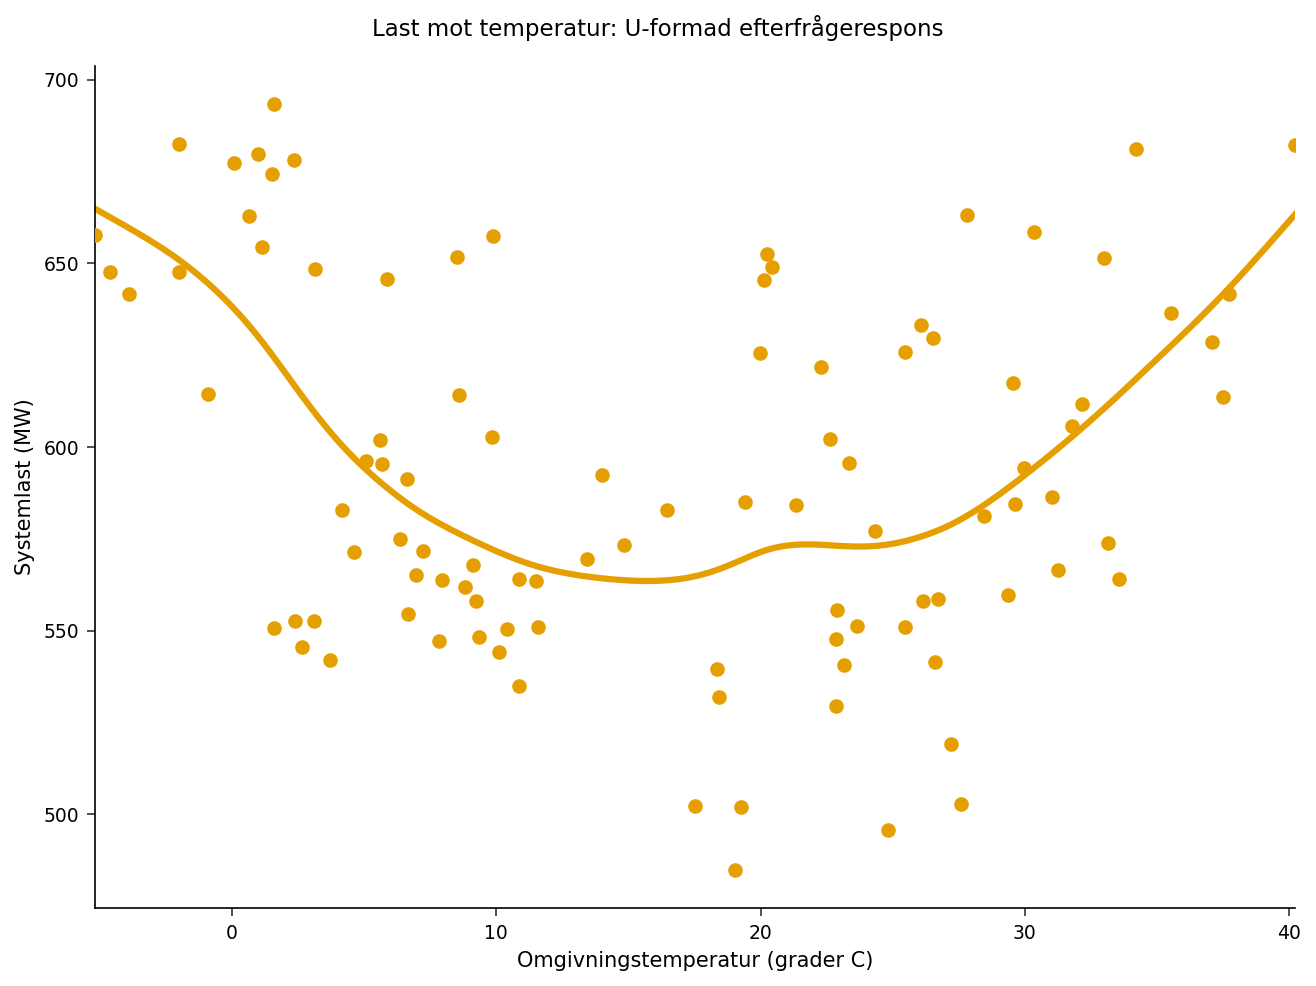

In [4]:
ODS GRAPHICS ON;

PROCEDUR SGPLOT data=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ETIKETT="Omgivningstemperatur (grader C)";
   YAXIS ETIKETT="Systemlast (MW)";
   TITEL "Last mot temperatur: U-formad efterfrågerespons";
KÖR;

ODS GRAPHICS OFF;

## Steg 5 — Bekräfta U-formen numeriskt

Diagrammet gör U-formen synlig; en bandad sammanställning gör den kvantitativ. Vi delar in observationerna i temperaturintervall och rapporterar medellast per band. Om efterfrågesvaret verkligen är U-format bör medellasten vara hög i bandet **Kallt**, sjunka genom **Svalt / Behagligt / Varmt**, och stiga igen i bandet **Hett** — den numeriska signatur som GAMPL:s utjämning `s(TEMP_C)` fångar upp.

In [5]:
data work.banded;
   STÄLL_IN work.gridload;
   LÄNGD tempband $13;
   OM      temp_c <  5  SÅ tempband = "1 Kallt";
   ANNARS OM temp_c < 15  SÅ tempband = "2 Svalt";
   ANNARS OM temp_c < 22  SÅ tempband = "3 Behagligt";
   ANNARS OM temp_c < 30  SÅ tempband = "4 Varmt";
   ANNARS                      tempband = "5 Hett";
KÖR;

PROCEDUR MEDELVÄRDEN data=work.banded n mean maxdec=1;
   KLASS tempband;
   VARIABEL load_mw;
   ETIKETT tempband="Temperaturband" load_mw="Systemlast (MW)";
   TITEL "Medellast per temperaturband";
KÖR;

                                              Medellast per temperaturband                                              

                                                  The MEANS Procedure

                                      Analysis Variable : load_mw Systemlast (MW)

        Temperaturband          N Obs           Mean
        --------------------------------------------
        1 Kallt                    21          626.6
        2 Svalt                    28          579.1
        3 Behagligt                12          573.8
        4 Varmt                    25          573.5
        5 Hett                     14          621.6
        --------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Tolkning av resultaten

**Utjämningarna återskapar fysiken.** GAMPL:s Smoothing Component-tabell tilldelar temperaturtermen `s(TEMP_C)` en effektiv frihetsgrad på 5,53 (*p* < 0,0001) och dygnstermen `s(HOUR)` en EDF på 6,87 (*p* < 0,0001) — båda genuint kurvade, precis den struktur vi byggde in i datat. Luftfuktighetstermen `s(HUMIDITY)` krymps till EDF 1,00 (*p* = 0,07): straffet rätar ut den till en enda nästan linjär frihetsgrad eftersom det, vid den här urvalsstorleken, är allt data stödjer. Den parametriska `daytype`-skattningen är −44,5 MW för helger, vilket återskapar den 40 MW-stora vardagsnivåförskjutningen i den genererande processen.

**Effektiva frihetsgrader berättar om kurvigheten.** Modellen förbrukar totalt 15,4 effektiva frihetsgrader och landar på ett GCV-värde på 239,6 (AIC 831,0, skalskattning 202,7). Att begränsa `maxdf=` och fästa `df=3` i Steg 3 flyttar knappt anpassningen (GCV 240,1, EDF 15,47): straffet hade redan lagt temperatur- och timutjämningarna nära 5,5 respektive 7 EDF på egen hand, så de manuella begränsningarna är icke-bindande här — ett tecken på att den automatiska urvalsprocessen redan var konservativ.

**Diagrammet och bandsammanställningen stämmer överens.** Spridningsdiagrammet i Steg 4 med sin straffade splineöverlagring visar att lasten sjunker från kylextremen till ett minimum nära 15-20 grader C och stiger igen mot värmen. Bandmedelvärdena i Steg 5 gör det numeriskt: **Kallt 626,6 MW**, **Svalt 579,1**, **Behagligt 573,8**, **Varmt 573,5**, **Hett 621,6** — högt i båda ändarna, lägst i det behagliga mittintervallet. Det U:et är precis vad en enda linjär `temp_c`-term skulle medelvärdesbort.

**Varför GAMPL framför linjär regression här.** En enda linjär `temp_c`-term skulle blanda ihop uppvärmnings- och kylningsregimerna till en nästan platt lutning, med kraftig felprognos i båda extremerna — precis de timmar då nätstress och prisspikar uppstår. Den additiva splineformuleringen behåller tolkningsbarheten hos en regression (varje drivkraft bidrar med en additiv effekt) samtidigt som data får diktera formen på varje effekt. Naturliga utökningar för ett elbolag inkluderar en `dist=gamma`-anpassning om lasten modelleras multiplikativt, en bivariat `spline(temp_c hour)` för att fånga hur dygnstoppen skiftar med säsong, och `by`-bearbetning för att anpassa separata modeller per transformatorstation.